In [1]:
import pandas as pd

df = pd.read_parquet('6번. 인코딩 및 데이터 변환.parquet')

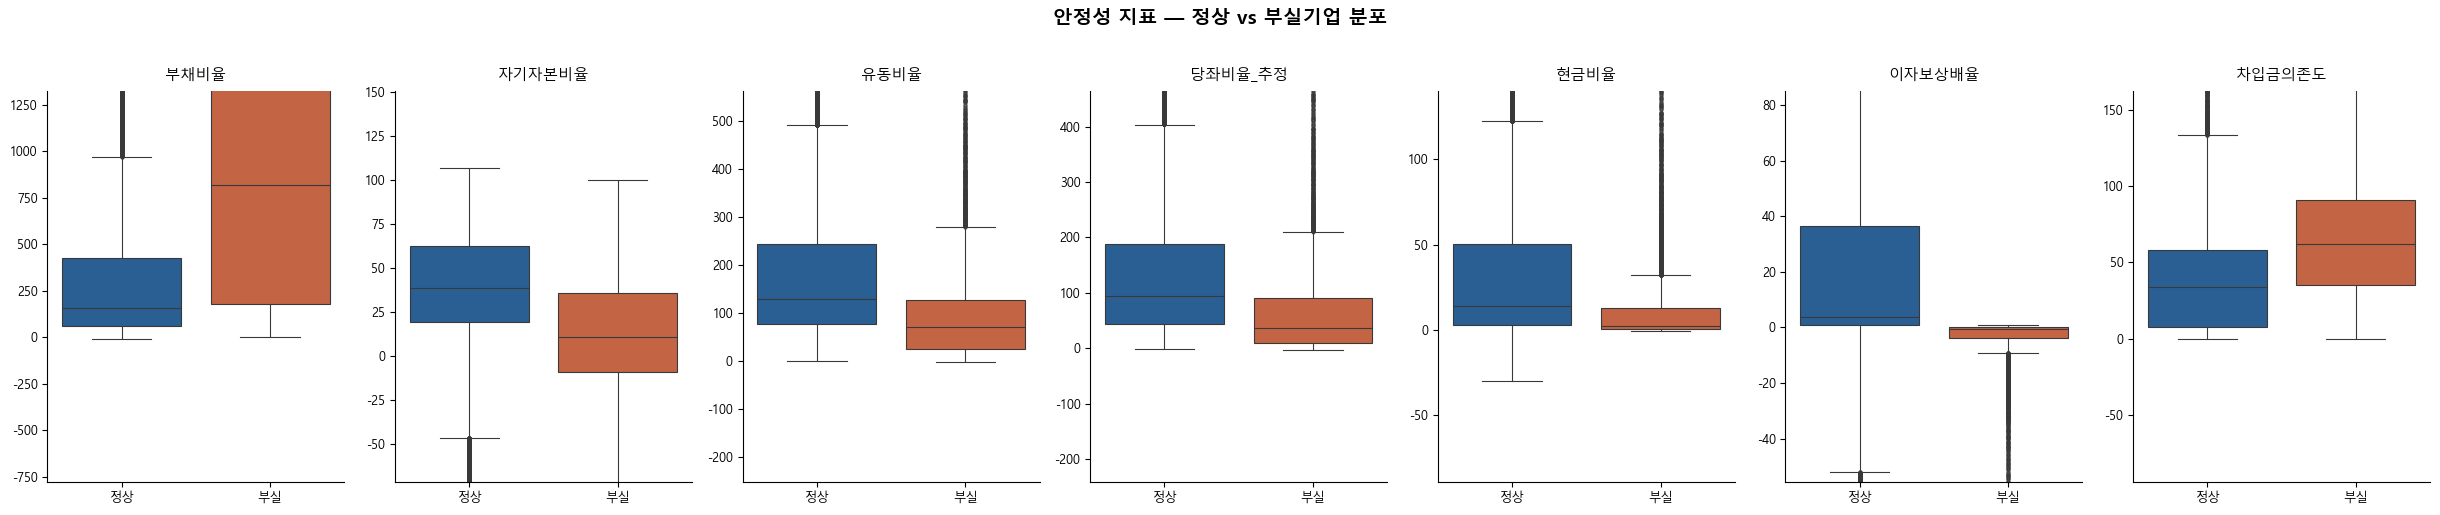

✅ 안정성 저장 완료


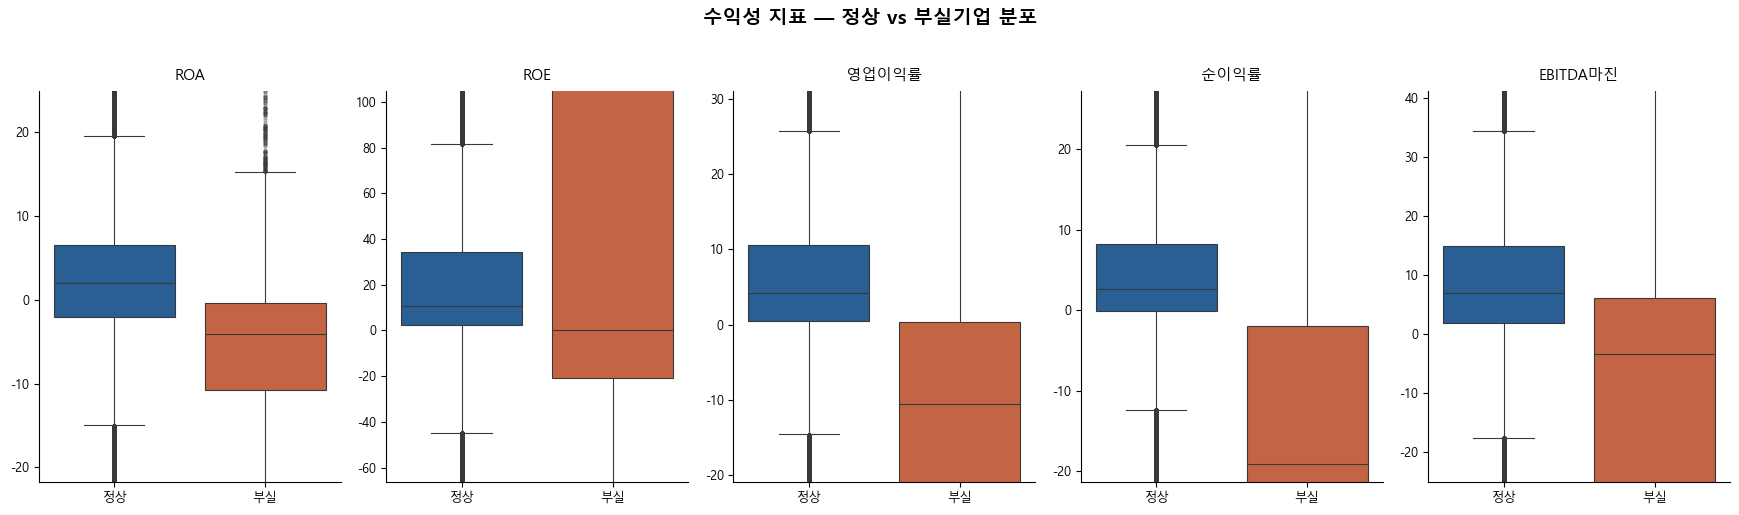

✅ 수익성 저장 완료


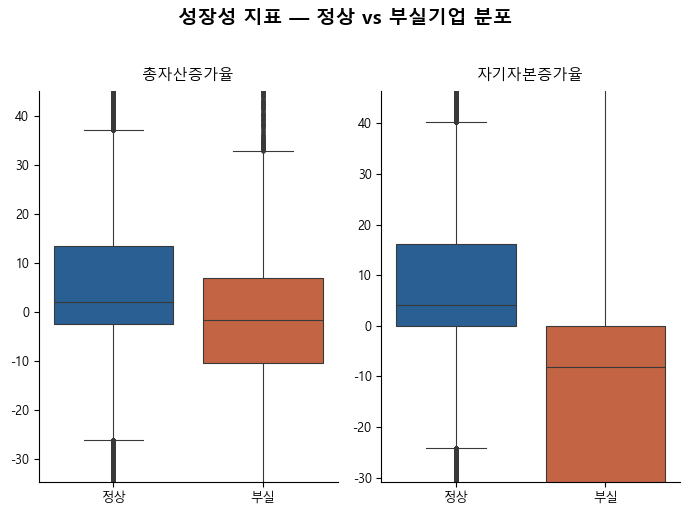

✅ 성장성 저장 완료


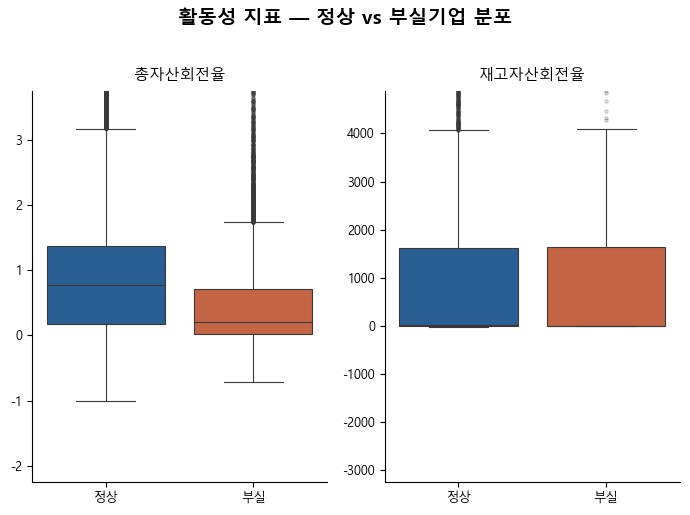

✅ 활동성 저장 완료


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

key_cols = {
    '안정성': ['부채비율', '자기자본비율', '유동비율', '당좌비율_추정', '현금비율', '이자보상배율', '차입금의존도'],
    '수익성': ['ROA', 'ROE', '영업이익률', '순이익률', 'EBITDA마진'],
    '성장성': ['총자산증가율', '자기자본증가율'],
    '활동성': ['총자산회전율', '재고자산회전율'],
}

all_cols = [col for cols in key_cols.values() for col in cols]

normal   = df[df['부실라벨_ICR3년'] == 0][all_cols].copy()
distress = df[df['부실라벨_ICR3년'] == 1][all_cols].copy()

normal['label']   = '정상'
distress['label'] = '부실'
plot_df = pd.concat([normal, distress], ignore_index=True)

colors = {'정상': '#185FA5', '부실': '#D85A30'}

for category, cols in key_cols.items():
    n_cols = len(cols)
    fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 3.5, 5))
    if n_cols == 1:
        axes = [axes]

    fig.suptitle(f'{category} 지표 — 정상 vs 부실기업 분포', fontsize=14, fontweight='bold', y=1.02)

    for ax, col in zip(axes, cols):
        sns.boxplot(
            data=plot_df,
            x='label', y=col,
            hue='label',
            palette=colors,
            order=['정상', '부실'],
            linewidth=0.8,
            flierprops=dict(marker='o', markersize=2, alpha=0.3),
            legend=False,
            ax=ax
        )

        # ✅ y축 범위를 IQR 기준으로 제한
        q1  = plot_df[col].quantile(0.25)
        q3  = plot_df[col].quantile(0.75)
        iqr = q3 - q1
        y_min = q1 - 2.0 * iqr
        y_max = q3 + 2.0 * iqr
        ax.set_ylim(y_min, y_max)

        ax.set_title(col, fontsize=11, pad=8)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(labelsize=9)
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()